In [ ]:
!pip install torch torchvision matplotlib scikit-learn seaborn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64)

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        return self.fc(x)

In [ ]:
def train(model, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):
        total_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss/len(trainloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}: {avg_loss}")

    return losses

In [ ]:
model1 = SimpleCNN().to(device)
loss1 = train(model1)

Epoch 1: 1.3623551040354287
Epoch 2: 1.012367705021368
Epoch 3: 0.8560707295870842
Epoch 4: 0.7553329234156767
Epoch 5: 0.6690640622163977


In [ ]:
from torchvision import models

model2 = models.resnet18(pretrained=True)
model2.fc = nn.Linear(model2.fc.in_features,10)
model2 = model2.to(device)

loss2 = train(model2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


Epoch 1: 0.9777307027517377
Epoch 2: 0.6574992766923002
Epoch 3: 0.519144673119573
Epoch 4: 0.41367945902030484
Epoch 5: 0.3360525985984394


Accuracy: 73.67


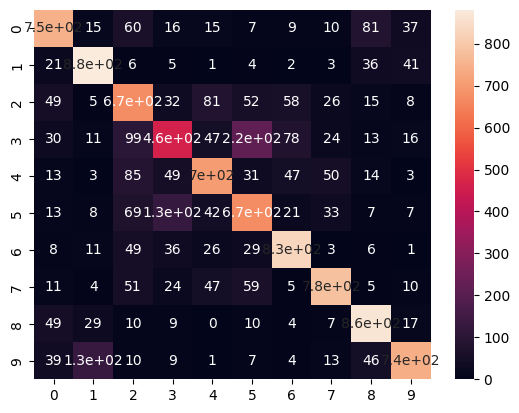

Accuracy: 79.62


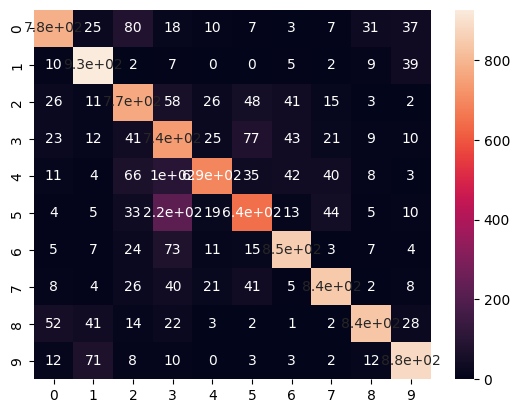

In [ ]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0
    preds, labels_list = [], []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            _, predicted = torch.max(output,1)

            correct += (predicted==labels).sum().item()
            total += labels.size(0)

            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    print("Accuracy:", 100*correct/total)

    cm = confusion_matrix(labels_list, preds)
    sns.heatmap(cm, annot=True)
    plt.show()

evaluate(model1)
evaluate(model2)

In [ ]:
def get_accuracy(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

acc1 = get_accuracy(model1)
acc2 = get_accuracy(model2)

print("Simple CNN Accuracy:", acc1)
print("ResNet18 Accuracy:", acc2)

Simple CNN Accuracy: 73.67
ResNet18 Accuracy: 79.62


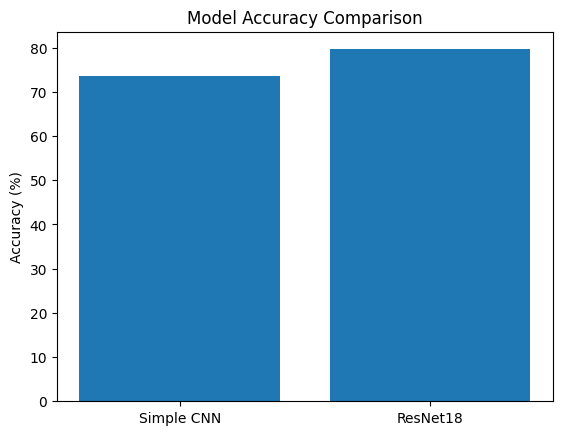

In [ ]:
models = ['Simple CNN', 'ResNet18']
accuracies = [acc1, acc2]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

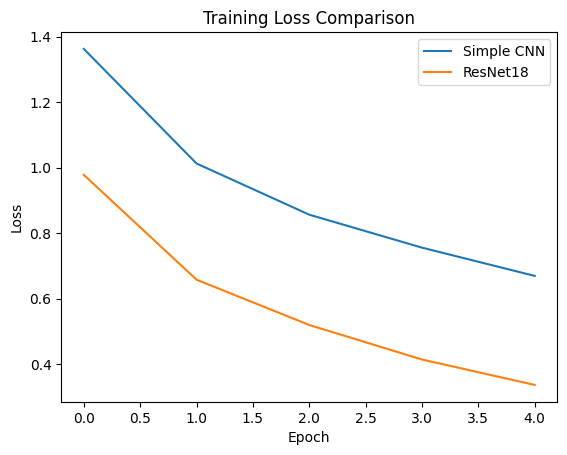

In [ ]:
plt.figure()
plt.plot(loss1, label='Simple CNN')
plt.plot(loss2, label='ResNet18')
plt.legend()
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

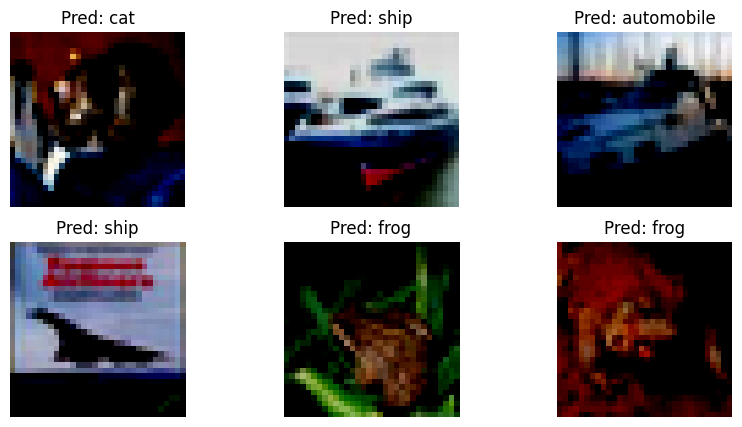

In [ ]:
classes = trainset.classes

images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

outputs = model2(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Pred: {classes[preds[i]]}")
    plt.axis('off')

plt.show()